# **Face Mask Detection using Transfer Learning**

# **Library Import**

In [1]:
from fastai.vision.all import *
from fastai.metrics import error_rate
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# **Setting up path for training data**

In [2]:
x  = r"C:\Users\rehan\Desktop\image project\Face Mask Dataset"
path = Path(x)
path.ls()

[Path('C:/Users/rehan/Desktop/image project/Face Mask Dataset/models'), Path('C:/Users/rehan/Desktop/image project/Face Mask Dataset/Test'), Path('C:/Users/rehan/Desktop/image project/Face Mask Dataset/Train'), Path('C:/Users/rehan/Desktop/image project/Face Mask Dataset/Validation')]

# **Data Loading**

In [ ]:
path = Path(r"C:\Users\rehan\Desktop\image project\Face Mask Dataset")  

data = ImageDataLoaders.from_folder(
    path,
    train='Train',
    valid='Validation',
    item_tfms=Resize(224),
    bs=32
)

# **Data Exploration**

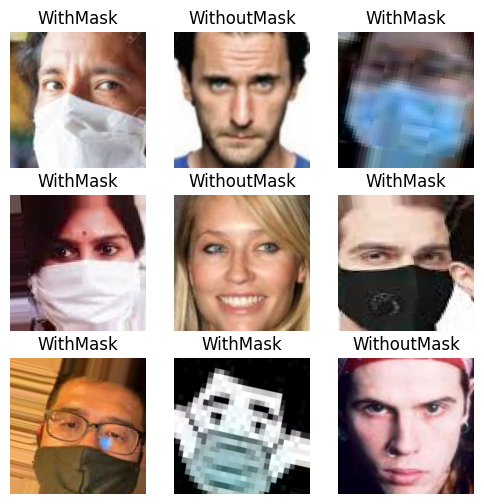

In [4]:
data.show_batch(max_n = 9 , figsize=(6,6))

In [5]:
print(data.vocab)
len(data.vocab)
data.c

['WithMask', 'WithoutMask']


2

# **Create Model**

In [6]:
learn = cnn_learner(data, resnet50, metrics=accuracy )

c:\Users\rehan\AppData\Local\Programs\Python\Python313\Lib\site-packages\fastai\vision\learner.py:303: UserWarning: `cnn_learner` has been renamed to `vision_learner` -- please update your code
  warn("`cnn_learner` has been renamed to `vision_learner` -- please update your code")


# **Finding LR**

<div></div>

SuggestedLRs(valley=0.001737800776027143)

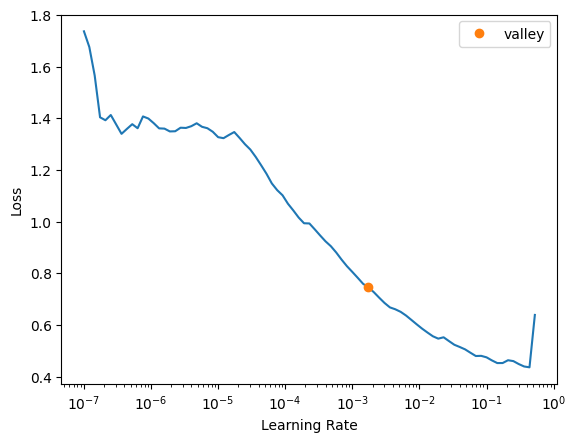

In [8]:
learn.lr_find()

# **Training Model**

In [10]:
lr1 = 1e-3
learn.fit_one_cycle(4,slice(lr1))

epoch,train_loss,valid_loss,accuracy,time
0,0.040386,0.015414,0.991250,23:54
1,0.026967,0.017034,0.993750,24:06
2,0.020548,0.010348,0.996250,26:31
3,0.019667,0.007192,0.997500,25:19


# **Hyper Parameter Tuning**

In [11]:
learn.unfreeze()
learn.fit_one_cycle(2,slice(1e-5,1e-3))

epoch,train_loss,valid_loss,accuracy,time
0,0.017365,0.009146,0.998750,36:09
1,0.012975,0.001850,1.000000,36:01


<Axes: title={'center': 'learning curve'}, xlabel='steps', ylabel='loss'>

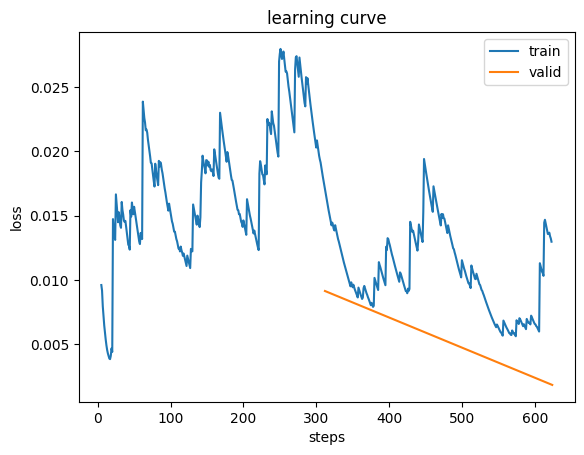

In [18]:
learn.recorder.plot_loss()

# **Interpret the result**

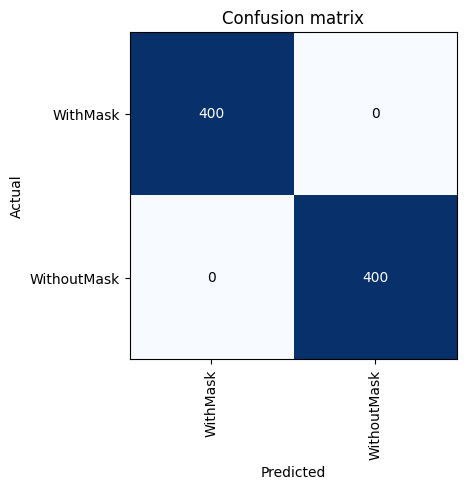

In [19]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

<div><progress max="1" value="0"></progress> 0.00% [0/1 00:00&lt;?]</div>

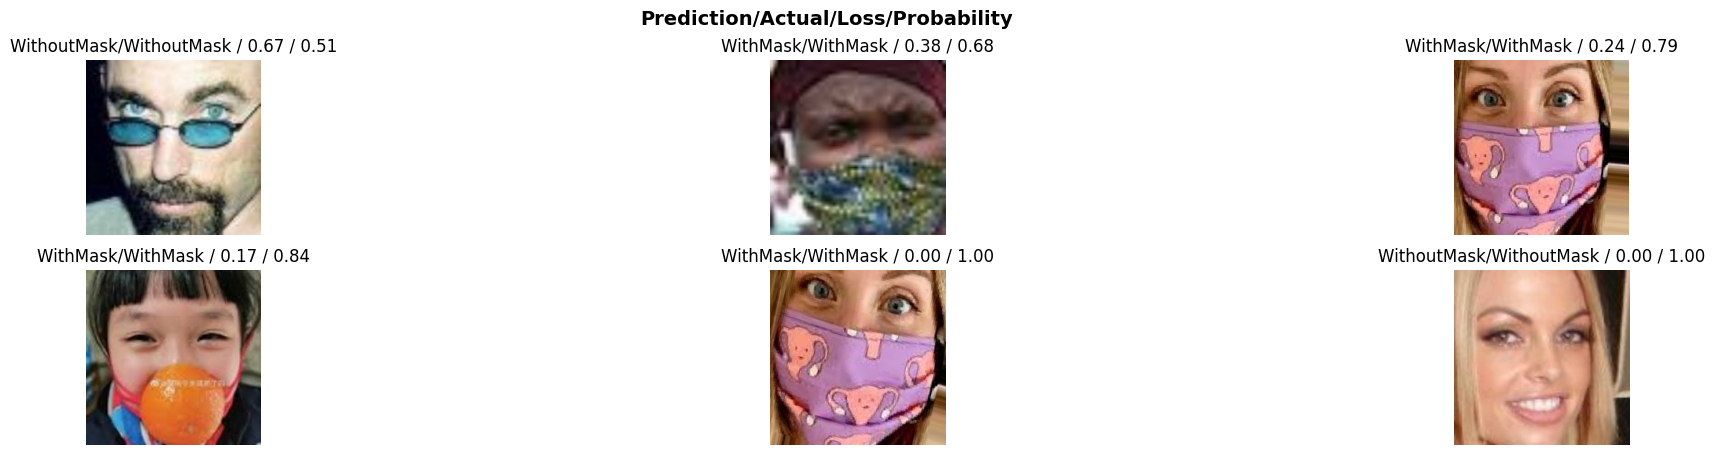

In [21]:
interp.plot_top_losses(6,figsize = (25,5))

In [24]:
# ===== Validation Accuracy =====
learn.dls = ImageDataLoaders.from_folder(
    path,
    train='Train',
    valid='Validation',
    item_tfms=Resize(224),
    bs=32
)

val_loss, val_acc = learn.validate()

# ===== Test Accuracy =====
learn.dls = ImageDataLoaders.from_folder(
    path,
    train='Train',
    valid='Test',
    item_tfms=Resize(224),
    bs=32
)

test_loss, test_acc = learn.validate()

# ===== Print Results =====
print("===== Model Performance =====")
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

===== Model Performance =====
Validation Loss: 0.1035
Validation Accuracy: 0.9762
Test Loss: 0.0926
Test Accuracy: 0.9657
